# SupportPilot AI — Baseline Model: TF-IDF + Logistic Regression

## Tujuan

Notebook ini digunakan untuk membangun baseline model
Intent Classification menggunakan:

- TF-IDF sebagai text feature extraction
- Logistic Regression sebagai classifier

Model dilatih menggunakan Training Set dan dievaluasi
menggunakan Validation Set.

Test Set tidak digunakan pada tahap ini agar tetap menjadi
unseen dataset untuk final evaluation.

Evaluasi mencakup:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Weighted F1-score
- Classification Report
- Analisis kesalahan prediksi
- Confusion analysis
- Training time
- Inference time

In [3]:
# import library
from pathlib import Path
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [4]:
# path
TRAIN_PATH = Path(
    "../data/processed/train.csv"
)

VALIDATION_PATH = Path(
    "../data/processed/validation.csv"
)

MODEL_DIR = Path(
    "../models"
)

REPORT_DIR = Path(
    "../reports/metrics"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [5]:
print("Train      :", TRAIN_PATH)
print("Validation :", VALIDATION_PATH)
print("Model dir  :", MODEL_DIR)
print("Report dir :", REPORT_DIR)

Train      : ..\data\processed\train.csv
Validation : ..\data\processed\validation.csv
Model dir  : ..\models
Report dir : ..\reports\metrics


In [6]:
# memastikan data tersedia
required_files = [
    TRAIN_PATH,
    VALIDATION_PATH,
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(
            f"File tidak ditemukan: {file_path}"
        )

print("Semua dataset ditemukan.")

Semua dataset ditemukan.


In [7]:
# load datset
train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

print(
    f"Train      : {len(train_df):,}"
)

print(
    f"Validation : {len(validation_df):,}"
)

Train      : 35,861
Validation : 4,483


In [8]:
# menentukan X dan y
FEATURE_COLUMN = "instruction"
TARGET_COLUMN = "intent"

X_train = train_df[
    FEATURE_COLUMN
]

y_train = train_df[
    TARGET_COLUMN
]

X_validation = validation_df[
    FEATURE_COLUMN
]

y_validation = validation_df[
    TARGET_COLUMN
]

In [9]:
print(
    f"X_train        : {X_train.shape}"
)

print(
    f"y_train        : {y_train.shape}"
)

print(
    f"X_validation   : {X_validation.shape}"
)

print(
    f"y_validation   : {y_validation.shape}"
)

print(
    f"Jumlah intent  : {y_train.nunique()}"
)

X_train        : (35861,)
y_train        : (35861,)
X_validation   : (4483,)
y_validation   : (4483,)
Jumlah intent  : 46


In [10]:
# buat TF-IDF + logistic regression pipeline
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

In [11]:
logistic_regression = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
)

In [12]:
# menggabungkan TF-IDF dan Logistic Regression ke dalam pipeline
model = Pipeline(
    steps=[
        (
            "tfidf",
            tfidf_vectorizer,
        ),
        (
            "classifier",
            logistic_regression,
        ),
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.95
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'st

In [13]:
# training model
start_train = time.perf_counter()

model.fit(
    X_train,
    y_train,
)

training_time = (
    time.perf_counter()
    - start_train
)

print(
    f"Training selesai dalam "
    f"{training_time:.2f} detik."
)

Training selesai dalam 3.79 detik.


In [14]:
# liat vocabulary 
tfidf_fitted = (
    model.named_steps["tfidf"]
)

vocabulary_size = len(
    tfidf_fitted.vocabulary_
)

print(
    f"Jumlah TF-IDF features: "
    f"{vocabulary_size:,}"
)

Jumlah TF-IDF features: 9,038


In [15]:
# predict validation
start_inference = time.perf_counter()

validation_predictions = model.predict(
    X_validation
)

inference_time = (
    time.perf_counter()
    - start_inference
)

In [16]:
average_inference_ms = (
    inference_time
    / len(X_validation)
    * 1000
)

print(
    f"Total inference time : "
    f"{inference_time:.4f} detik"
)

print(
    f"Rata-rata per sample : "
    f"{average_inference_ms:.4f} ms"
)

Total inference time : 0.0640 detik
Rata-rata per sample : 0.0143 ms


In [17]:
# hitung metrik evaluasi
accuracy = accuracy_score(
    y_validation,
    validation_predictions,
)

macro_precision = precision_score(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0,
)

macro_recall = recall_score(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0,
)

macro_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="weighted",
    zero_division=0,
)

In [18]:
metrics_summary = pd.DataFrame(
    {
        "metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted F1",
        ],
        "score": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_f1,
        ],
    }
)

metrics_summary["score"] = (
    metrics_summary["score"]
    .round(4)
)

metrics_summary

,metric,score
0,Accuracy,0.9824
1,Macro Precision,0.9831
2,Macro Recall,0.9826
3,Macro F1,0.9826
4,Weighted F1,0.9824


In [19]:
# classification report
report = classification_report(
    y_validation,
    validation_predictions,
    output_dict=True,
    zero_division=0,
)

report_df = (
    pd.DataFrame(report)
    .transpose()
)

report_df

,precision,recall,f1-score,support
add_product,1.000000,1.000000,1.000000,96.000000
availability,0.959596,0.989583,0.974359,96.000000
availability_in_store,0.986667,0.986667,0.986667,75.000000
availability_online,0.989899,0.989899,0.989899,99.000000
cancel_order,0.989899,0.989899,0.989899,99.000000
change_account,0.960784,0.989899,0.975124,99.000000
change_order,1.000000,1.000000,1.000000,96.000000
close_account,1.000000,0.960000,0.979592,100.000000
customer_service,1.000000,1.000000,1.000000,99.000000
damaged_delivery,0.990000,1.000000,0.994975,99.000000


In [20]:
# intent dengan f1 terburuk
intent_report = (
    report_df
    .loc[
        model.classes_,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
    .sort_values(
        "f1-score"
    )
)

intent_report.head(10)

,precision,recall,f1-score,support
return_product,0.904762,0.959596,0.931373,99.0
return_policy,0.988764,0.888889,0.936170,99.0
track_order,0.988889,0.898990,0.941799,99.0
return_product_online,0.968085,0.919192,0.943005,99.0
track_delivery,0.900901,1.000000,0.947867,100.0
refund_status,0.969388,0.950000,0.959596,100.0
submit_product_feedback,0.942308,0.980000,0.960784,100.0
submit_feedback,0.960000,0.969697,0.964824,99.0
refund_policy,0.934579,1.000000,0.966184,100.0
availability,0.959596,0.989583,0.974359,96.0


In [21]:
# intent terbaik
intent_report.tail(10)

,precision,recall,f1-score,support
change_order,1.0,1.0,1.0,96.0
add_product,1.0,1.0,1.0,96.0
customer_service,1.0,1.0,1.0,99.0
missing_item,1.0,1.0,1.0,72.0
remove_product,1.0,1.0,1.0,99.0
recover_password,1.0,1.0,1.0,100.0
payment_methods,1.0,1.0,1.0,99.0
store_opening_hours,1.0,1.0,1.0,99.0
technical_issue,1.0,1.0,1.0,99.0
use_app,1.0,1.0,1.0,100.0


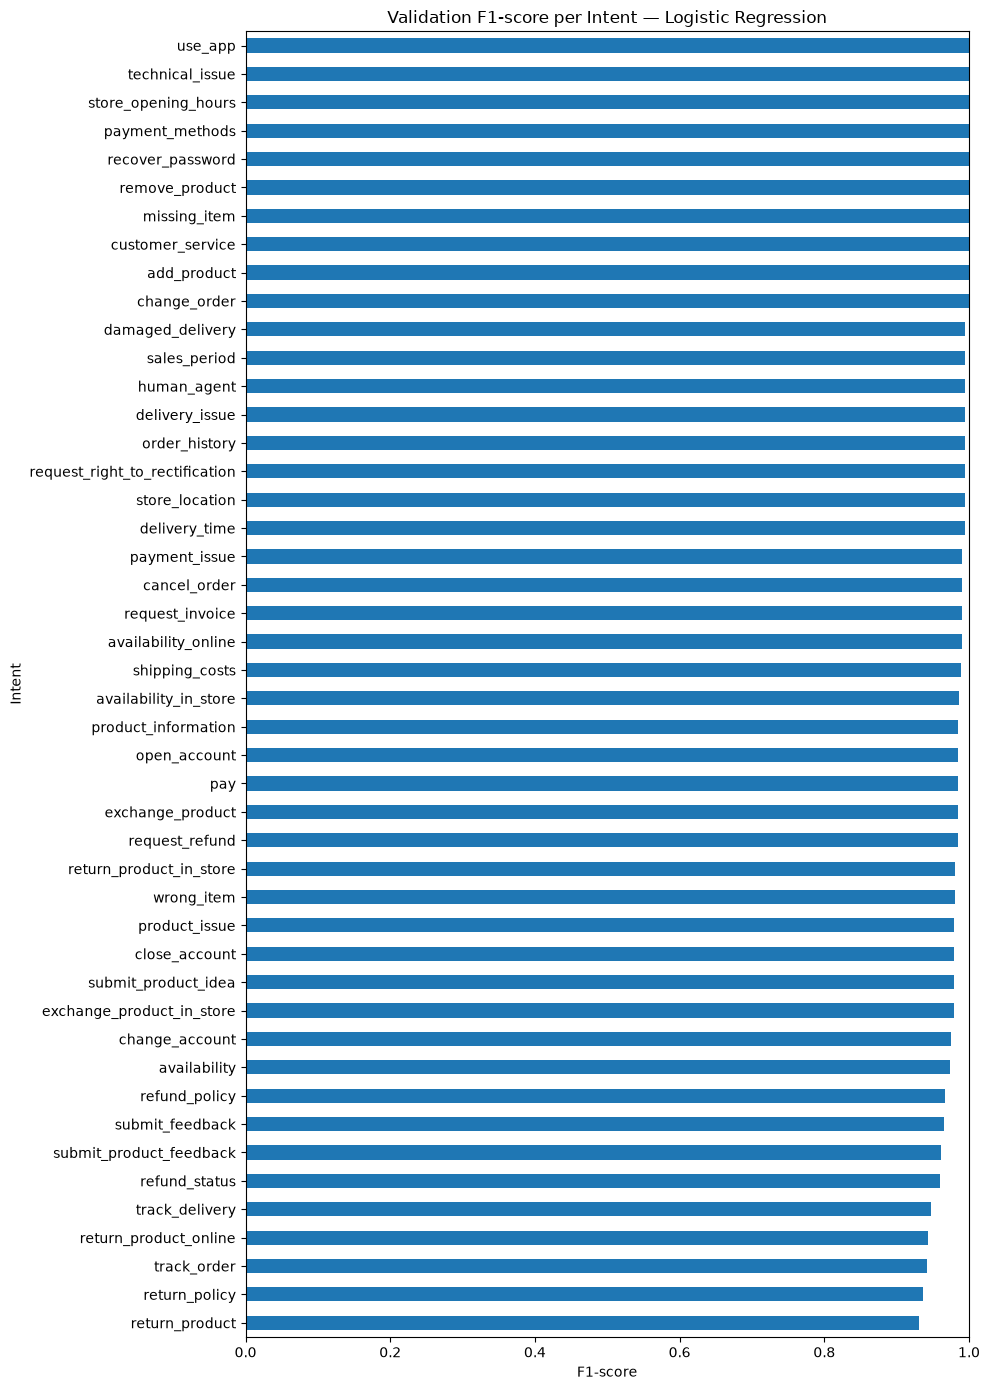

In [22]:
# visualisasi f1 per intent
(
    intent_report["f1-score"]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(10, 14),
    )
)

plt.title(
    "Validation F1-score per Intent — Logistic Regression"
)

plt.xlabel(
    "F1-score"
)

plt.ylabel(
    "Intent"
)

plt.xlim(
    0,
    1,
)

plt.tight_layout()

plt.show()

In [23]:
# analisis prediksi salah
validation_results = (
    validation_df[
        [
            "instruction",
            "intent",
            "category",
        ]
    ]
    .copy()
)

validation_results[
    "predicted_intent"
] = validation_predictions

validation_results[
    "is_correct"
] = (
    validation_results["intent"]
    == validation_results[
        "predicted_intent"
    ]
)

In [24]:
errors = (
    validation_results[
        ~validation_results["is_correct"]
    ]
)

print(
    f"Prediksi benar : "
    f"{validation_results['is_correct'].sum():,}"
)

print(
    f"Prediksi salah : "
    f"{len(errors):,}"
)

print(
    f"Error rate     : "
    f"{len(errors) / len(validation_results):.2%}"
)

Prediksi benar : 4,404
Prediksi salah : 79
Error rate     : 1.76%


In [25]:
# liat contoh kesalahan
errors[
    [
        "instruction",
        "intent",
        "predicted_intent",
    ]
].head(20)

,instruction,intent,predicted_intent
22,need to report fuckingdelivery issues help me,delivery_issue,product_issue
34,could I retirn some fucking products in store?,return_policy,availability_in_store
108,im trying to find my fucking order historh i n...,order_history,track_order
196,i have to submit a fucking commenthelp me,submit_feedback,submit_product_feedback
203,I'd like to see ur fucking retutn policy how t...,return_policy,refund_policy
222,i have prodcut feedback send it,submit_product_feedback,submit_feedback
232,"I ogt to see where my shipment is, how can I d...",track_order,track_delivery
368,id like to registre how can i do it,open_account,pay
520,how can I see where my package is?,track_order,track_delivery
533,i got to track my fucking erfund help me,refund_status,track_delivery


In [26]:
# analisis confusion pair
labels = sorted(
    y_validation.unique()
)

cm = confusion_matrix(
    y_validation,
    validation_predictions,
    labels=labels,
)

In [27]:
confusion_pairs = []

for true_index, true_label in enumerate(labels):
    for pred_index, predicted_label in enumerate(labels):

        if true_label == predicted_label:
            continue

        count = cm[
            true_index,
            pred_index,
        ]

        if count > 0:
            confusion_pairs.append(
                {
                    "actual_intent": true_label,
                    "predicted_intent": predicted_label,
                    "count": count,
                }
            )

In [28]:
confusion_df = (
    pd.DataFrame(
        confusion_pairs
    )
    .sort_values(
        "count",
        ascending=False,
    )
)

confusion_df.head(15)

,actual_intent,predicted_intent,count
30,return_product_online,return_product,8
24,return_policy,refund_policy,7
40,track_order,track_delivery,7
20,refund_status,track_delivery,4
39,track_order,refund_status,3
12,exchange_product_in_store,return_product_in_store,3
5,close_account,change_account,3
25,return_policy,return_product_online,3
18,product_issue,wrong_item,2
28,return_product,submit_product_feedback,2


### Interpretasi Confusion Pair

Kesalahan prediksi paling sering terjadi pada intent yang memiliki
kemiripan semantik dan vocabulary.

Beberapa confusion pair utama adalah:

- `return_product_online` → `return_product`
- `return_policy` → `refund_policy`
- `track_order` → `track_delivery`
- `refund_status` → `track_delivery`
- `exchange_product_in_store` → `return_product_in_store`
- `submit_feedback` ↔ `submit_product_feedback`

Temuan ini menunjukkan bahwa TF-IDF + Logistic Regression mampu
mengenali keyword dengan sangat baik, tetapi masih memiliki
keterbatasan ketika dua intent menggunakan vocabulary dan konteks
yang sangat mirip.

Beberapa kesalahan dengan frekuensi rendah juga menunjukkan adanya
kalimat yang ambigu atau noisy pada dataset synthetic.

Temuan ini akan digunakan sebagai salah satu dasar perbandingan
dengan model Linear SVM dan Transformer.

In [29]:
# confidence model
validation_probabilities = (
    model.predict_proba(
        X_validation
    )
)

validation_confidence = (
    validation_probabilities
    .max(axis=1)
)

validation_results[
    "confidence"
] = validation_confidence

In [30]:
validation_results[
    "confidence"
].describe()

count    4483.000000
mean        0.891531
std         0.148961
min         0.079776
25%         0.877867
50%         0.952262
75%         0.977869
max         0.998674
Name: confidence, dtype: float64

In [31]:
# lihat error dengan confidence tertinggi
high_confidence_errors = (
    validation_results[
        ~validation_results[
            "is_correct"
        ]
    ]
    .sort_values(
        "confidence",
        ascending=False,
    )
)

high_confidence_errors[
    [
        "instruction",
        "intent",
        "predicted_intent",
        "confidence",
    ]
].head(15)


,instruction,intent,predicted_intent,confidence
833,how to return a fucking item online,return_policy,return_product_online,0.909931
3435,need to see where my package is will ya help me,track_order,track_delivery,0.885556
520,how can I see where my package is?,track_order,track_delivery,0.875589
3535,i have to see the availability of an item onoi...,availability_online,availability,0.865796
3191,id like to return an order onloine where could...,return_product_online,return_product,0.862066
3631,"I want to see were my shipment is, how can I d...",track_order,track_delivery,0.788034
4310,is it possible to see where my shipment is ?,track_order,track_delivery,0.774844
4322,i got to return an order onlie where do i do it,return_product_online,return_product,0.734754
232,"I ogt to see where my shipment is, how can I d...",track_order,track_delivery,0.729972
4005,I want to check the status of my replacementpr...,track_order,refund_status,0.686507


In [32]:
# ambil vectorizer dan classifier
tfidf_model = (
    model.named_steps["tfidf"]
)

classifier_model = (
    model.named_steps[
        "classifier"
    ]
)

feature_names = (
    tfidf_model
    .get_feature_names_out()
)

In [33]:
def show_top_features(
    intent,
    top_n=10,
):
    class_index = list(
        classifier_model.classes_
    ).index(intent)

    coefficients = (
        classifier_model
        .coef_[class_index]
    )

    top_indices = (
        np.argsort(
            coefficients
        )[-top_n:]
        [::-1]
    )

    return pd.DataFrame(
        {
            "feature": (
                feature_names[
                    top_indices
                ]
            ),
            "weight": (
                coefficients[
                    top_indices
                ]
            ),
        }
    )

In [34]:
show_top_features(
    "track_order",
    top_n=15,
)

,feature,weight
0,replacement,7.068284
1,my,5.580887
2,my replacement,4.929364
3,order,4.858249
4,my exchange,4.577050
5,status,4.081943
6,where my,4.032135
7,status of,3.656869
8,track,3.642406
9,exchange,3.315895


In [35]:
show_top_features(
    "cancel_order",
    top_n=15,
)

,feature,weight
0,cancel,9.554316
1,to cancel,5.645471
2,order,5.143063
3,canceling,4.003029
4,cancel fucking,3.616518
5,placed,3.267645
6,cancelling,3.075592
7,want it,2.787926
8,online order,2.702711
9,cancel an,2.672363


In [36]:
show_top_features(
    "payment_issue",
    top_n=15,
)

,feature,weight
0,payment,8.644189
1,problem,4.028752
2,card,3.735751
3,notify,3.398503
4,fucking payment,3.308360
5,payment problems,3.215647
6,notify of,3.207050
7,payment issue,3.071675
8,problems,3.027659
9,payment issues,2.943801


In [37]:
# simpan metric
metrics = {
    "model": (
        "TF-IDF + Logistic Regression"
    ),
    "validation_records": int(
        len(validation_df)
    ),
    "accuracy": float(
        accuracy
    ),
    "macro_precision": float(
        macro_precision
    ),
    "macro_recall": float(
        macro_recall
    ),
    "macro_f1": float(
        macro_f1
    ),
    "weighted_f1": float(
        weighted_f1
    ),
    "training_time_seconds": float(
        training_time
    ),
    "inference_time_seconds": float(
        inference_time
    ),
    "average_inference_ms": float(
        average_inference_ms
    ),
    "vocabulary_size": int(
        vocabulary_size
    ),
}

In [38]:
METRICS_PATH = (
    REPORT_DIR
    / "logistic_regression_validation_metrics.json"
)

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metrics,
        file,
        indent=4,
    )

print(
    f"Metrics disimpan ke:\n"
    f"{METRICS_PATH}"
)

Metrics disimpan ke:
..\reports\metrics\logistic_regression_validation_metrics.json


In [39]:
# simpan model 
MODEL_PATH = (
    MODEL_DIR
    / "tfidf_logistic_regression.joblib"
)

joblib.dump(
    model,
    MODEL_PATH,
)

print(
    f"Model disimpan ke:\n"
    f"{MODEL_PATH}"
)

Model disimpan ke:
..\models\tfidf_logistic_regression.joblib


In [40]:
# test model hasil save
loaded_model = joblib.load(
    MODEL_PATH
)

sample_questions = [
    "where is my order",
    "I want to cancel my order",
    "my payment is not working",
    "I need to return my product",
]

sample_predictions = (
    loaded_model.predict(
        sample_questions
    )
)

pd.DataFrame(
    {
        "question": sample_questions,
        "predicted_intent": (
            sample_predictions
        ),
    }
)

,question,predicted_intent
0,where is my order,track_order
1,I want to cancel my order,cancel_order
2,my payment is not working,payment_issue
3,I need to return my product,return_product


## Kesimpulan Baseline Model

Model baseline menggunakan pendekatan **TF-IDF + Logistic Regression**
untuk melakukan multiclass Intent Classification terhadap 46 intent.

Model dilatih menggunakan Training Set dan dievaluasi menggunakan
Validation Set. Test Set belum digunakan agar tetap menjadi unseen
dataset untuk final evaluation.

### Hasil Validation

- Accuracy: **98.24%**
- Macro Precision: **98.31%**
- Macro Recall: **98.26%**
- Macro F1-score: **98.26%**
- Weighted F1-score: **98.24%**
- Training Time: **3.79 detik**
- Total Validation Inference Time: **0.0640 detik**
- Average Inference Time: **0.0143 ms/sample**
- TF-IDF Vocabulary Size: **9,038 features**

### Temuan Utama

Model Logistic Regression menghasilkan performa baseline yang sangat
tinggi dan memiliki inference time yang sangat cepat.

Sebagian besar kesalahan terjadi pada intent yang memiliki kemiripan
semantik, seperti:

- `track_order` dan `track_delivery`
- `return_policy` dan `return_product_online`
- `return_product` dan `return_product_online`
- `submit_feedback` dan `submit_product_feedback`
- `pay` dan `payment_issue`

Analisis coefficient menunjukkan bahwa model memanfaatkan kata dan
frasa yang berkaitan dengan masing-masing intent. Sebagai contoh,
feature seperti `cancel`, `to cancel`, dan `order` memiliki weight
tinggi pada class `cancel_order`.

Namun, beberapa feature yang sangat dominan juga menunjukkan pola
template dari dataset synthetic. Oleh karena itu, validation score
yang tinggi belum dapat langsung dianggap merepresentasikan performa
pada customer query dunia nyata.

Hasil baseline ini akan digunakan sebagai pembanding untuk model
berikutnya, yaitu **TF-IDF + Linear SVM**.